In [86]:
import pandas as pd
import numpy as np
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
from funcoes.funcoes_exploratoria import *
from scipy import stats

In [ ]:
# Importando o df
df_original = pd.read_csv('../raw/data_raw.csv')
df_original

In [ ]:
analise_dados(df_original)

In [ ]:
# Correção do datetime
df_tratado = df_original.copy()
df_tratado['date'] = pd.to_datetime(df_tratado['date'])
df_tratado['date'].astype

In [ ]:
analise_dados(df_tratado)

In [6]:
# Confirmando os id repetidos
df_id = df_tratado[df_tratado.duplicated(subset=['id'], keep=False)] 
df_id.sort_values(by='id')

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
2496,1000102,2014-09-16,280000.0,6,3.00,2400,9373,2.0,0,0,...,7,2400.0,0,1991,0,98002,47.3262,-122.214,2060,7316
2497,1000102,2015-04-22,300000.0,6,3.00,2400,9373,2.0,0,0,...,7,2400.0,0,1991,0,98002,47.3262,-122.214,2060,7316
16814,7200179,2014-10-16,150000.0,2,1.00,840,12750,1.0,0,0,...,6,840.0,0,1925,0,98055,47.4840,-122.211,1480,6969
16815,7200179,2015-04-24,175000.0,2,1.00,840,12750,1.0,0,0,...,6,840.0,0,1925,0,98055,47.4840,-122.211,1480,6969
11433,109200390,2014-08-20,245000.0,3,1.75,1480,3900,1.0,0,0,...,7,1480.0,0,1980,0,98023,47.2977,-122.367,1830,6956
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6345,9828200460,2014-06-27,260000.0,2,1.00,700,4800,1.0,0,0,...,7,700.0,0,1922,0,98122,47.6147,-122.300,1440,4800
15200,9834200305,2015-02-10,615000.0,3,1.00,1790,3876,1.5,0,0,...,7,1090.0,700,1904,0,98144,47.5750,-122.288,1360,4080
15199,9834200305,2014-07-16,350000.0,3,1.00,1790,3876,1.5,0,0,...,7,1090.0,700,1904,0,98144,47.5750,-122.288,1360,4080
1086,9834200885,2015-04-20,550000.0,4,2.50,2080,4080,1.0,0,0,...,7,1040.0,1040,1962,0,98144,47.5720,-122.290,1340,4080


In [ ]:
# Visualizando nulos
df_nulos = df_tratado[df_tratado.isna().any(axis=1)]
df_nulos

In [ ]:
# Ver se não se repete pelo id --> (Não deu)
df_comparar = df_tratado[df_tratado['id']==6865200140]
df_comparar

In [9]:
# Confirmando hipotese de area construida ser porão + geral
df_area = df_tratado[['sqft_living','sqft_above','sqft_basement']]
df_area['hipotese_soma'] = df_area['sqft_above'] + df_area['sqft_basement']
diferencas = df_area[df_area['hipotese_soma'] != df_area['sqft_living']]
diferencas

C:\Users\gio_m\AppData\Local\Temp\ipykernel_10664\919201466.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_area['hipotese_soma'] = df_area['sqft_above'] + df_area['sqft_basement']


,sqft_living,sqft_above,sqft_basement,hipotese_soma
10,3560,NaN,1700,NaN
17,1600,NaN,0,NaN


In [ ]:
# Retirando os nulos
df_semnulos = df_tratado.copy()
df_semnulos['sqft_above'] = df_semnulos['sqft_living'] - df_semnulos['sqft_basement'] 
df_tratado_final = df_semnulos[df_semnulos.isna().any(axis=1)]
df_tratado_final

In [ ]:
# Conferindo tratamento inicial
analise_dados(df_semnulos)

In [12]:
# Salvando o dataframe sem nulos ou duplicados
df_semnulos.to_csv('../processed/df_tratado_nulos_duplicados.csv', index=False, sep=';', encoding='utf-8-sig')

In [ ]:
resumo_estatistico(df_semnulos)

In [61]:
df_novascolunas = df_semnulos.copy()
#-------------------------------------------------------------------------
df_novascolunas['living_more_lot'] = (df_novascolunas['sqft_living'] + df_novascolunas['sqft_lot']).round(2)
df_novascolunas['living_percent_total'] = (df_novascolunas['sqft_living'] / df_novascolunas['living_more_lot']).round(2)
df_novascolunas['lot_percent_total'] = (df_novascolunas['sqft_lot'] / df_novascolunas['living_more_lot']).round(2)
#-------------------------------------------------------------------------
df_novascolunas['price_for_living'] = (df_novascolunas['price'] * df_novascolunas['living_percent_total']).round(2)
df_novascolunas['price_for_lot'] = (df_novascolunas['price'] * df_novascolunas['lot_percent_total']).round(2)
#-------------------------------------------------------------------------
df_novascolunas['percent_construcao_porao'] = np.where(
    df_novascolunas['sqft_basement'] > 0,
    ((df_novascolunas['sqft_basement'] / df_novascolunas['sqft_living'])).round(2),0.0).round(2)

df_novascolunas['percent_construcao_above'] = (1 - df_novascolunas['percent_construcao_porao']).round(2)
#-------------------------------------------------------------------------
df_novascolunas['living_price_for_basement'] = (df_novascolunas['price_for_living'] * df_novascolunas['percent_construcao_porao']).round(2)
df_novascolunas['living_price_for_above'] = (df_novascolunas['price_for_living'] * df_novascolunas['percent_construcao_above']).round(2)
#-------------------------------------------------------------------------
df_novascolunas['lot_15_compare'] =  (df_novascolunas['sqft_lot']/df_novascolunas['sqft_lot15']).round(2)
df_novascolunas['living_15_compare'] = (df_novascolunas['sqft_living']/df_novascolunas['sqft_living15']).round(2)
#-------------------------------------------------------------------------
df_novascolunas['mean_price_zipcode'] = (df_novascolunas.groupby('zipcode')['price'].transform('mean')).round(2)
df_novascolunas['zipcode_compare'] = (df_novascolunas['price']/df_novascolunas['mean_price_zipcode']).round(2)
#-------------------------------------------------------------------------
df_novascolunas['age'] = 2026 - df_novascolunas['yr_built']

df_novascolunas['age_renovated'] = np.where(
    df_novascolunas['yr_renovated'] == 0, 
    df_novascolunas['age'], 
    2026 - df_novascolunas['yr_renovated']
).round(2)
#-------------------------------------------------------------------------
df_novascolunas['bool_renovated'] = np.where(df_novascolunas['yr_renovated'] > 0, 1, 0)
df_novascolunas['bool_basement'] = np.where(df_novascolunas['sqft_basement'] > 0, 1, 0)
df_novascolunas['living_more_than_lot'] = np.where(df_novascolunas['sqft_living'] >= df_novascolunas['sqft_lot'], 1, 0)
df_novascolunas['bool_renovated'] = np.where(df_novascolunas['age_renovated'] < df_novascolunas['age'], 1, 0)
df_novascolunas['bool_renovated_20'] = np.where(df_novascolunas['age_renovated'] < 20, 1, 0)
df_novascolunas['bool_renovated_10'] = np.where(df_novascolunas['age_renovated'] < 15, 1, 0)


In [ ]:
df_novascolunas['age_renovated'].describe()

In [63]:
df_novascolunas.to_csv('../processed/df_novascolunas.csv', index=False, sep=';', encoding='utf-8-sig')

In [ ]:
df_novascolunas.columns

In [ ]:
lista_vazamento = ['id', 'date','yr_built','zipcode','lat','long','price_for_living','price_for_lot','living_price_for_basement','living_price_for_above','zipcode_compare' ]

df_sem_vazamento = df_novascolunas.drop(columns=lista_vazamento)
df_sem_vazamento

In [67]:
df_sem_vazamento.to_csv('../processed/df_sem_vazamento.csv', index=False, sep=';', encoding='utf-8-sig')

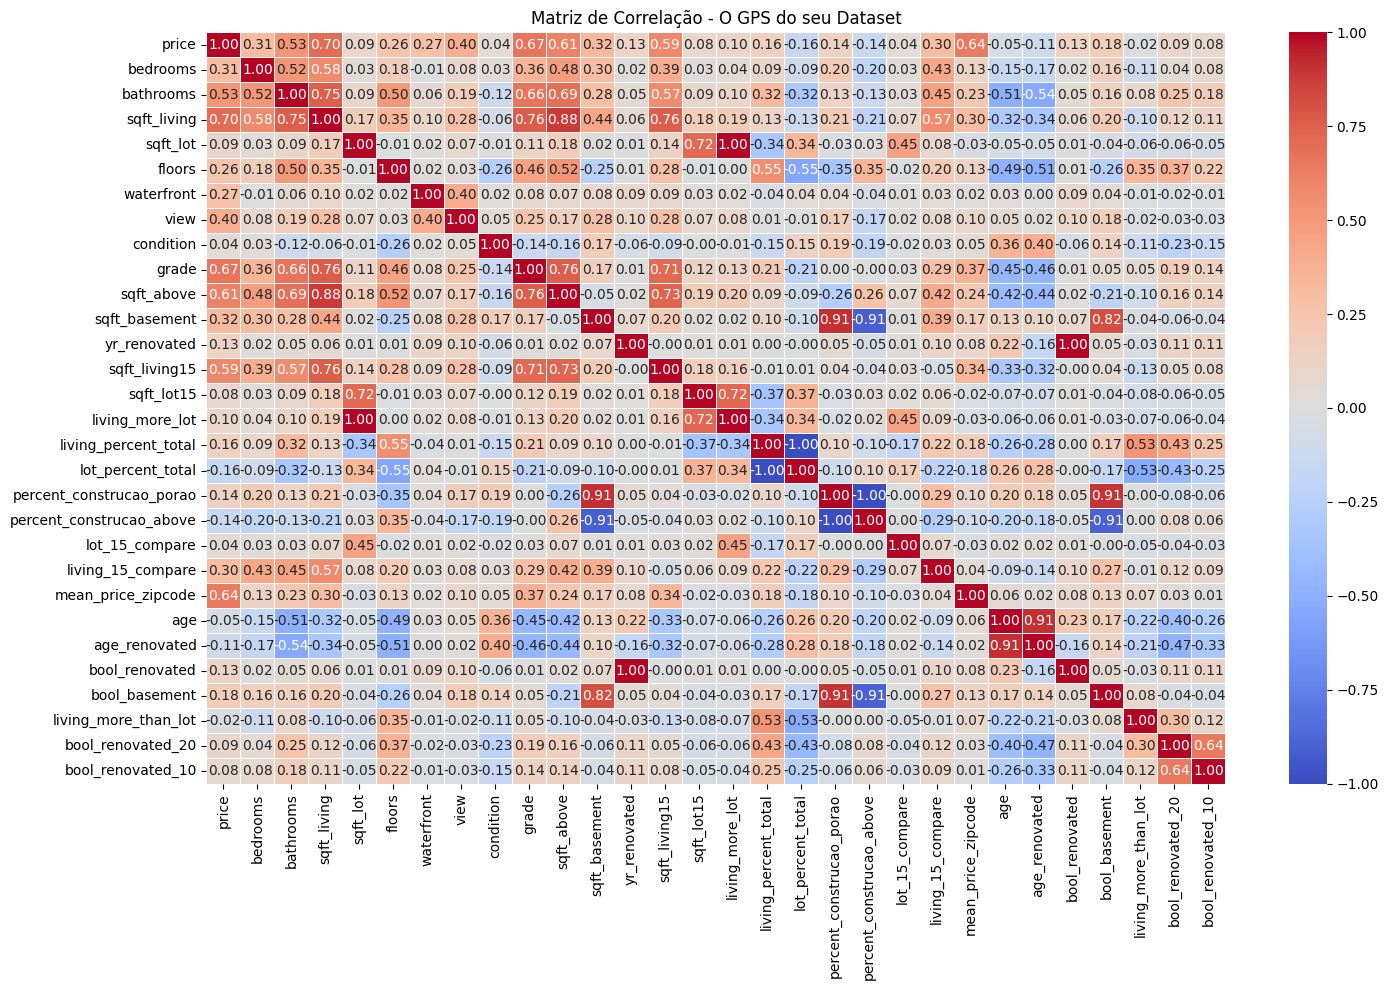

In [68]:
import matplotlib.pyplot as plt 
import seaborn as sns 

plt.figure(figsize=(15, 10))
sns.heatmap(df_sem_vazamento.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação - O GPS do seu Dataset')
plt.tight_layout()
plt.show()

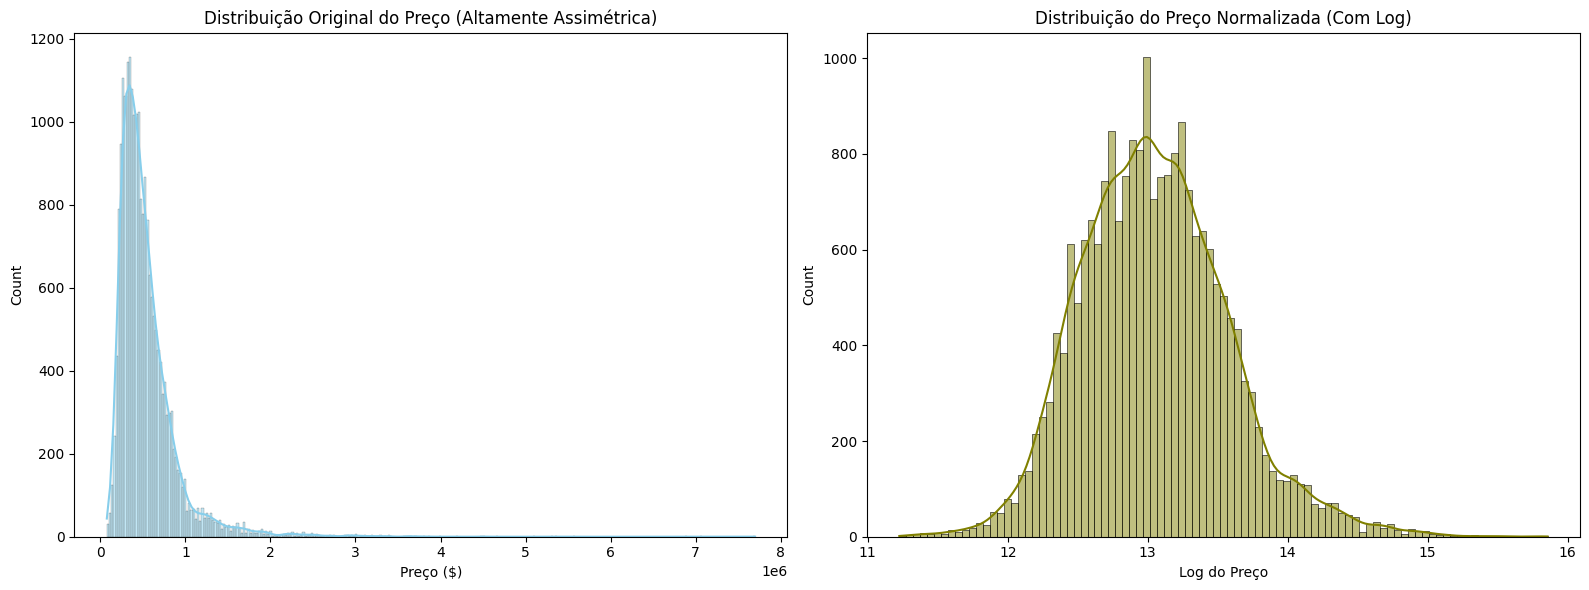

In [69]:
df_eda = df_sem_vazamento.copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico da esquerda: Preço original
sns.histplot(df_eda['price'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribuição Original do Preço (Altamente Assimétrica)')
axes[0].set_xlabel('Preço ($)')

# Gráfico da direita: Preço escalado em Logaritmo
sns.histplot(np.log1p(df_eda['price']), kde=True, ax=axes[1], color='olive')
axes[1].set_title('Distribuição do Preço Normalizada (Com Log)')
axes[1].set_xlabel('Log do Preço')

plt.tight_layout()
plt.show()

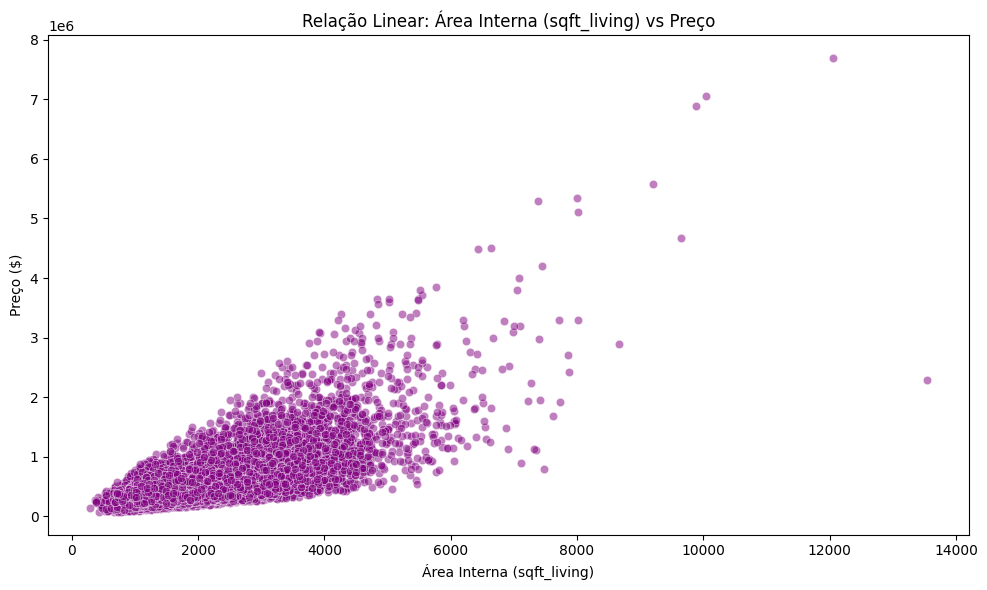

In [79]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_eda, x='sqft_living', y='price', alpha=0.5, color='purple')

plt.title('Relação Linear: Área Interna (sqft_living) vs Preço')
plt.xlabel('Área Interna (sqft_living)')
plt.ylabel('Preço ($)')
plt.tight_layout()
plt.show()

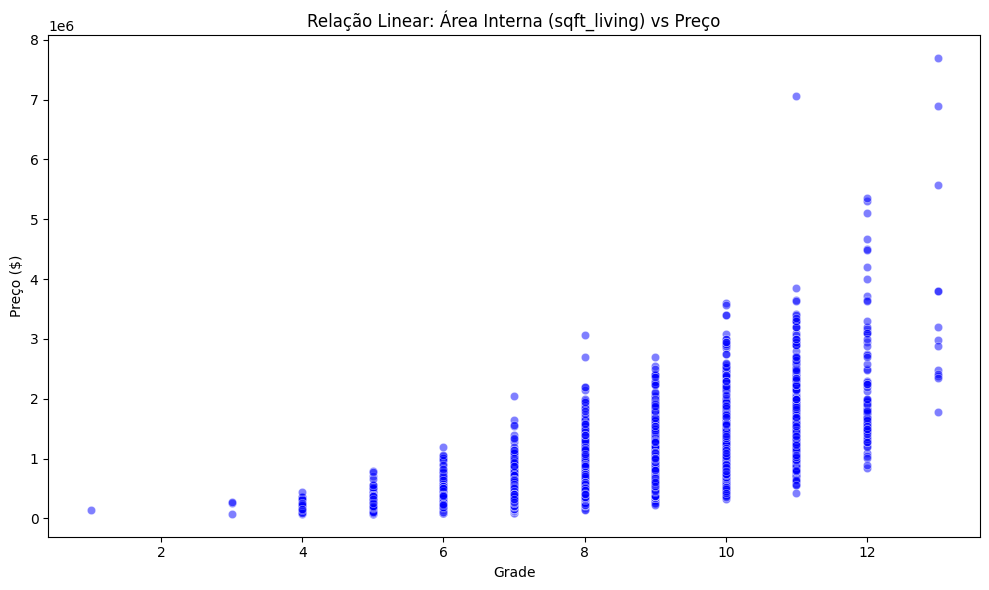

In [78]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_eda, x='grade', y='price', alpha=0.5, color='blue')

plt.title('Relação Linear: Área Interna (sqft_living) vs Preço')
plt.xlabel('Grade')
plt.ylabel('Preço ($)')
plt.tight_layout()
plt.show()

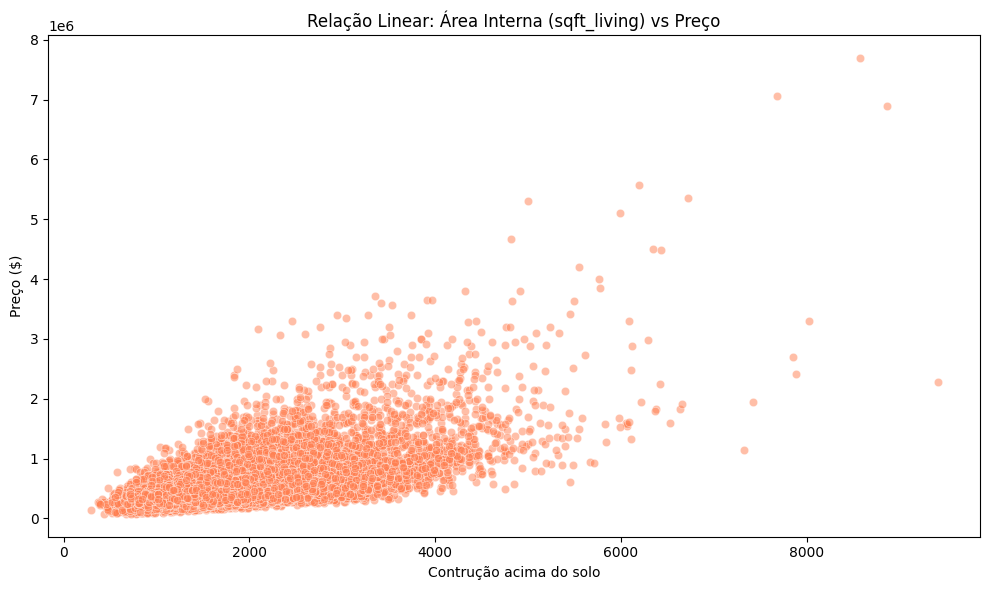

In [73]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_eda, x='sqft_above', y='price', alpha=0.5, color='coral')

plt.title('Relação Linear: Área Interna (sqft_living) vs Preço')
plt.xlabel('Contrução acima do solo')
plt.ylabel('Preço ($)')
plt.tight_layout()
plt.show()

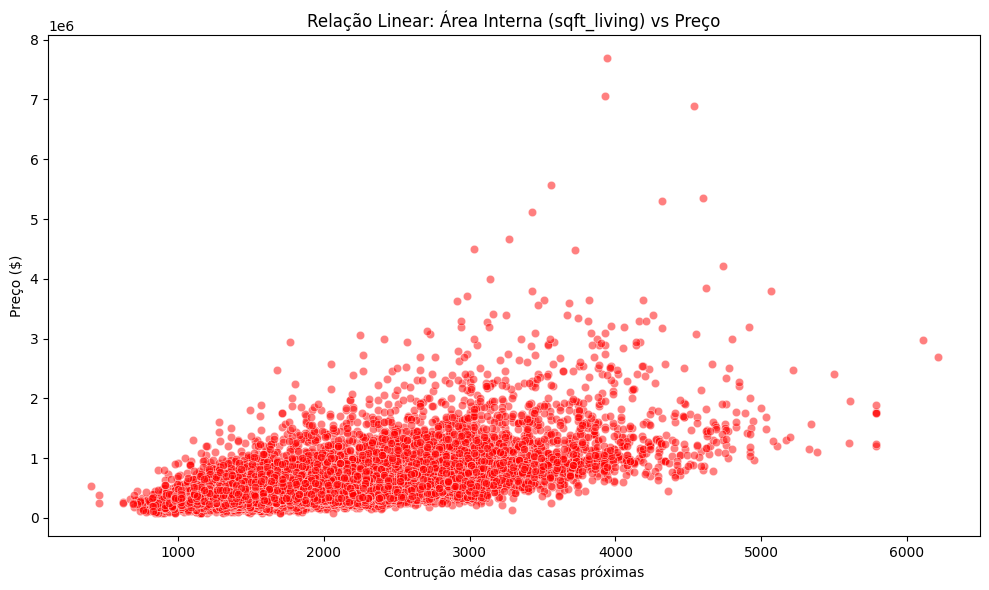

In [75]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_eda, x='sqft_living15', y='price', alpha=0.5, color='red')

plt.title('Relação Linear: Área Interna (sqft_living) vs Preço')
plt.xlabel('Contrução média das casas próximas')
plt.ylabel('Preço ($)')
plt.tight_layout()
plt.show()

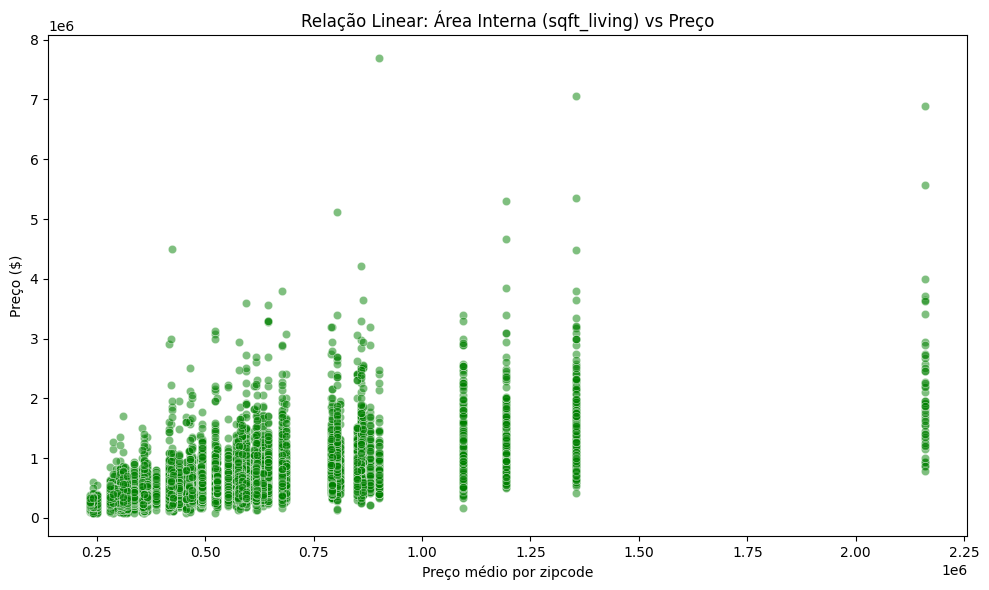

In [77]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_eda, x='mean_price_zipcode', y='price', alpha=0.5, color='green')

plt.title('Relação Linear: Área Interna (sqft_living) vs Preço')
plt.xlabel('Preço médio por zipcode')
plt.ylabel('Preço ($)')
plt.tight_layout()
plt.show()

In [88]:


# 2. Filtra apenas as colunas numéricas (ignora IDs se houver)
colunas_numericas = df_eda.select_dtypes(include=[np.number]).columns.tolist()
if 'id' in colunas_numericas:
    colunas_numericas.remove('id')

# Dicionário para guardar as tabelas com as linhas inteiras de outliers de cada coluna
outliers_por_coluna = {}

print("=== INICIANDO ANÁLISE DE OUTLIERS POR COLUNA ===\n")

for col in colunas_numericas:
    # Ignora colunas binárias ou categóricas com poucos valores únicos (ex: waterfront, floors)
    if df_eda[col].nunique() <= 5:
        continue
        
    # Remove nulos apenas para o cálculo estatístico
    dados_limpos = df_eda[col].dropna()
    
    # 3. Teste de Normalidade (D'Agostino & Pearson)
    # H0: Os dados seguem uma distribuição normal (se p_valor > 0.05, aceitamos H0)
    stat, p_valor = stats.normaltest(dados_limpos)
    alpha = 0.05
    dist_normal = p_valor > alpha
    
    # 4. Define o método de detecção baseado na normalidade
    if dist_normal:
        # Distribuição Normal -> Z-Score (Moderação de 3 desvios padrão)
        z_scores = np.abs(stats.zscore(dados_limpos))
        mascara_outliers = z_scores > 3
        metodo = "Z-Score (Normal)"
    else:
        # Distribuição Não-Normal -> IQR (Amplitude Interquartílica)
        q1 = dados_limpos.quantile(0.25)
        q3 = dados_limpos.quantile(0.75)
        iqr = q3 - q1
        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr
        mascara_outliers = (dados_limpos < limite_inferior) | (dados_limpos > limite_superior)
        metodo = "IQR (Não-Normal)"
        
    # 5. Extrai as LINHAS INTEIRAS do DataFrame original que são outliers nesta coluna
    linhas_outliers = df_eda[df_eda[col].isin(dados_limpos[mascara_outliers])]
    
    # Salva no dicionário para você poder acessar depois
    outliers_por_coluna[col] = linhas_outliers
    
    # Exibe o diagnóstico no console
    print(f"Coluna: '{col}'")
    print(f"  - Distribuição Normal? {'SIM' if dist_normal else 'NÃO'} (p-valor: {p_valor:.5f})")
    print(f"  - Método aplicado: {metodo}")
    print(f"  - Total de outliers nesta coluna: {len(linhas_outliers)} linhas")
    print("-" * 60)

print("\n=== ANÁLISE CONCLUÍDA ===")
print("Para acessar as linhas inteiras de outliers de uma coluna específica, use:")
print("outliers_por_coluna['nome_da_coluna']")

=== INICIANDO ANÁLISE DE OUTLIERS POR COLUNA ===

Coluna: 'price'
  - Distribuição Normal? NÃO (p-valor: 0.00000)
  - Método aplicado: IQR (Não-Normal)
  - Total de outliers nesta coluna: 1146 linhas
------------------------------------------------------------
Coluna: 'bedrooms'
  - Distribuição Normal? NÃO (p-valor: 0.00000)
  - Método aplicado: IQR (Não-Normal)
  - Total de outliers nesta coluna: 546 linhas
------------------------------------------------------------
Coluna: 'bathrooms'
  - Distribuição Normal? NÃO (p-valor: 0.00000)
  - Método aplicado: IQR (Não-Normal)
  - Total de outliers nesta coluna: 571 linhas
------------------------------------------------------------
Coluna: 'sqft_living'
  - Distribuição Normal? NÃO (p-valor: 0.00000)
  - Método aplicado: IQR (Não-Normal)
  - Total de outliers nesta coluna: 572 linhas
------------------------------------------------------------
Coluna: 'sqft_lot'
  - Distribuição Normal? NÃO (p-valor: 0.00000)
  - Método aplicado: IQR (Não

In [92]:
outliers_por_coluna['price'].sort_values

<bound method DataFrame.sort_values of            price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
5      1225000.0         4       4.50         5420    101930     1.0   
21     2000000.0         3       2.75         3050     44867     1.0   
49     1350000.0         3       2.50         2753     65005     1.0   
69     1325000.0         5       2.25         3200     20158     1.0   
125    1450000.0         4       2.75         2750     17789     1.5   
...          ...       ...        ...          ...       ...     ...   
21568  1700000.0         4       3.50         3830      8963     2.0   
21576  3567000.0         5       4.50         4850     10584     2.0   
21590  1222500.0         4       3.50         4910      9444     1.5   
21597  1575000.0         4       3.25         3410     10125     2.0   
21600  1537000.0         5       3.75         4470      8088     2.0   

       waterfront  view  condition  grade  ...  lot_15_compare  \
5               0     0       